### **Code Cell: Import Libraries for Data Generation**

This cell imports necessary libraries:
- `make_classification` from `sklearn.datasets`: Used to generate a synthetic dataset for classification tasks.
- `numpy` as `np`: A fundamental package for numerical computing in Python, providing support for arrays and mathematical functions.

In [2]:
from sklearn.datasets import make_classification
import numpy as np


### **Code Cell: Generate Synthetic Dataset**

This cell generates a synthetic 2D classification dataset using `make_classification` with the following parameters:
- `n_samples=500`: Creates 500 data points.
- `n_features=2`: Each data point will have 2 features (dimensions).
- `n_informative=2`: Both features are informative, meaning they contribute to separating the classes.
- `n_redundant=0`: No redundant features.
- `n_classes=2`: Generates two distinct classes.
- `n_clusters_per_class=1`: Each class consists of a single cluster of points.
- `random_state=42`: Ensures reproducibility of the dataset.
- `hypercube=False`: Places class clusters randomly within the feature space.
- `class_sep=15`: Sets a high separation between the classes, making them clearly distinguishable.

The `X` variable stores the feature data, and `y` stores the corresponding class labels. The shapes of `X` and `y` are then printed to confirm the dataset dimensions.

In [3]:

X,y =make_classification(n_samples=500,
                         n_features=2,n_informative=2,n_redundant=0,
                         n_classes=2,n_clusters_per_class=1,
                         random_state=42,hypercube=False,class_sep=15
                         )
print(X.shape,y.shape)

(500, 2) (500,)


### **Code Cell: Visualize the Generated Dataset**

This cell uses `matplotlib.pyplot` to visualize the synthetic dataset:
- `import matplotlib.pyplot as plt`: Imports the plotting library.
- `plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.Spectral)`: Creates a scatter plot where:
    - `X[:,0]` represents the first feature on the x-axis.
    - `X[:,1]` represents the second feature on the y-axis.
    - `c=y`: Colors the data points according to their class labels (`y`).
    - `cmap=plt.cm.Spectral`: Uses the 'Spectral' colormap for distinct class colors.
- `plt.show()`: Displays the generated plot.

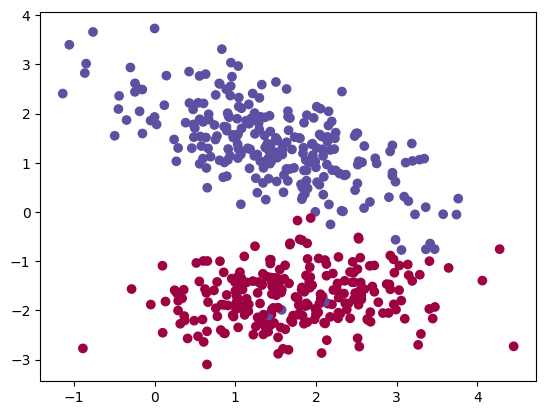

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.Spectral)
plt.show()

### **Code Cell: Import Libraries for Logistic Regression**

This cell imports the necessary components from `sklearn` for building and evaluating a Logistic Regression model:
- `LogisticRegression` from `sklearn.linear_model`: The class for implementing logistic regression.
- `train_test_split` from `sklearn.model_selection`: A utility to split arrays or matrices into random train and test subsets.
- `accuracy_score` from `sklearn.metrics`: A function to calculate the accuracy of a classification model.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### **Code Cell: Split Data into Training and Testing Sets**

This cell splits the dataset `X` and `y` into training and testing sets:
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`:
    - `test_size=0.2`: Allocates 20% of the data for the test set and 80% for the training set.
    - `random_state=42`: Ensures that the data split is consistent and reproducible.

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### **Code Cell: Initialize Logistic Regression Model**

This cell initializes a `LogisticRegression` model:
- `lor = LogisticRegression(penalty=None, solver='sag')`:
    - `penalty=None`: Disables regularization (L1 or L2 penalty).
    - `solver='sag'`: Specifies the 'Stochastic Average Gradient' algorithm for optimization. This solver is suitable for large datasets.

In [7]:
lor=LogisticRegression(penalty=None,solver='sag')



### **Code Cell: Train the Logistic Regression Model**

This cell trains the initialized `LogisticRegression` model using the training data:
- `lor.fit(X_train, y_train)`: The `fit` method learns the optimal coefficients and intercept from the training features (`X_train`) and their corresponding labels (`y_train`).

In [8]:
lor.fit(X_train,y_train)

LogisticRegression(penalty=None, solver='sag')

### **Evaluation: Scikit-learn Model Accuracy**

Now we evaluate how well the Scikit-learn model performs on unseen data (the test set).

In [21]:
y_pred = lor.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy Score: 97.00%


### **Confusion Matrix**

While accuracy is helpful, a confusion matrix shows exactly where the model is making mistakes (e.g., misclassifying class 0 as class 1).

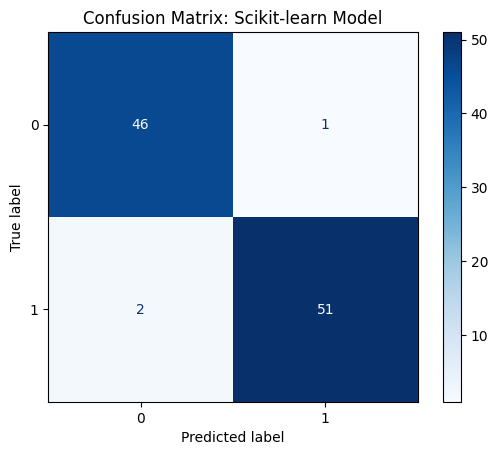

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Scikit-learn Model')
plt.show()

### **Code Cell: Display Model Coefficients and Intercept**

This cell prints the learned parameters of the logistic regression model:
- `print(lor.coef_, lor.intercept_)`:
    - `lor.coef_`: Displays the coefficients (weights) assigned to each feature. These represent the impact of each feature on the log-odds of the positive class.
    - `lor.intercept_`: Shows the intercept term, which is the log-odds of the positive class when all features are zero.

In [9]:
print(lor.coef_,lor.intercept_)

[[0.81212026 4.20835554]] [-0.05012562]


### **Code Cell: Calculate Decision Boundary Parameters (Scikit-learn Model)**

This cell calculates the slope (`m1`) and y-intercept (`b1`) of the decision boundary line derived from the Scikit-learn Logistic Regression model's coefficients and intercept.

For a logistic regression model, the decision boundary is where the log-odds are zero:
`coef_[0]*x1 + coef_[1]*x2 + intercept_ = 0`

Rearranging to `x2 = m*x1 + b`:
- `m1 = -(lor.coef_[0][0] / lor.coef_[0][1])`: Calculates the slope of the decision boundary.
- `b1 = -(lor.intercept_[0] / lor.coef_[0][1])`: Calculates the y-intercept of the decision boundary.

In [10]:
m1= -(lor.coef_[0][0]/lor.coef_[0][1])
b1=-(lor.intercept_[0]/lor.coef_[0][1])

### **Code Cell: Generate Points for Decision Boundary Line (Scikit-learn Model)**

This cell generates `x` and `y` coordinates to plot the decision boundary line learned by the Scikit-learn Logistic Regression model:
- `x_input = np.linspace(-3, 3, 100)`: Creates an array of 100 evenly spaced values between -3 and 3 for the x-axis.
- `y_input = m1 * x_input + b1`: Uses the previously calculated slope (`m1`) and intercept (`b1`) to determine the corresponding `y` values for each `x_input`, defining the decision boundary line.

In [11]:
x_input = np.linspace(-3,3,100)
y_input=m1*x_input + b1

### **Extended Gradient Descent: Tracking Loss**

To ensure our custom gradient descent is working efficiently, we can track the 'Log Loss' (cost) at each iteration and plot it.

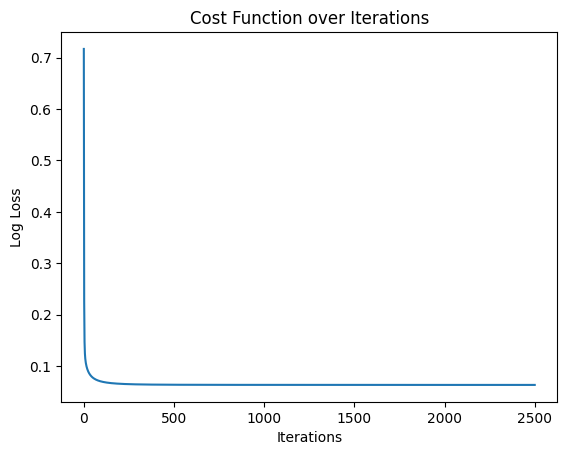

In [22]:
def gd_with_cost(X, y, iterations=2500, lr=0.5):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    cost_history = []

    for i in range(iterations):
        y_hat = sigmoid(np.dot(X, weights))
        # Log Loss calculation
        cost = -(1/X.shape[0]) * np.sum(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))
        cost_history.append(cost)

        weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])

    return weights[1:], weights[0], cost_history

coef_custom, intercept_custom, costs = gd_with_cost(X_train, y_train)

plt.plot(range(len(costs)), costs)
plt.title("Cost Function over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.show()

### **Code Cell: Implement Gradient Descent Function**

This cell defines a custom `gd` function to perform gradient descent for logistic regression. This function aims to find the optimal weights (coefficients and intercept) iteratively.

- `X = np.insert(X, 0, 1, axis=1)`: Adds a column of ones to the feature matrix `X`. This is for the intercept term, allowing it to be treated as another weight during calculation.
- `weights = np.ones(X.shape[1])`: Initializes all weights (including the intercept) to 1.
- `lr = 0.5`: Sets the learning rate, controlling the step size during weight updates.
- The `for` loop runs for 2500 iterations:
    - `y_hat = sigmoid(np.dot(X, weights))`: Calculates the predicted probabilities using the current weights and the `sigmoid` function.
    - `weights = weights + lr * (np.dot((y - y_hat), X) / X.shape[0])`: Updates the weights based on the gradient of the loss function. The error `(y - y_hat)` is multiplied by `X` to get the gradient, which is then scaled by the learning rate and added to the current weights.
- `return weights[1:], weights[0]`: Returns the learned coefficients (excluding the intercept) and the intercept term separately.

In [14]:
def gd(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr=0.5
  for i in range(2500):
    y_hat=sigmoid(np.dot(X,weights))
    weights = weights + lr *(np.dot((y - y_hat),X)/X.shape[0])

  return weights[1:],weights[0]


### **Code Cell: Implement Sigmoid Activation Function**

This cell defines the `sigmoid` function, which is crucial for logistic regression:
- `def sigmoid(z): return 1 / (1 + np.exp(-z))`: The sigmoid function (also known as the logistic function) maps any real-valued number to a value between 0 and 1. In logistic regression, it converts the linear combination of features and weights into a probability.

In [15]:
def sigmoid(z):
  return 1/(1+ np.exp(-z))



### **Code Cell: Run Custom Gradient Descent**

This cell calls the `gd` function, our custom implementation of gradient descent, to learn the logistic regression parameters using the training data:
- `coef_, intercept_ = gd(X_train, y_train)`: Executes the gradient descent algorithm, returning the learned coefficients (excluding the intercept) as `coef_` and the intercept term as `intercept_`.

In [16]:
coef_,intercept_=gd(X_train,y_train)


### **Code Cell: Calculate Decision Boundary Parameters (Custom GD Model)**

Similar to the Scikit-learn model, this cell calculates the slope (`m`) and y-intercept (`b`) of the decision boundary line derived from the coefficients and intercept obtained from the custom `gd` function.

- `m = -(coef_[0] / coef_[1])`: Calculates the slope of the decision boundary.
- `b = -(intercept_ / coef_[1])`: Calculates the y-intercept of the decision boundary.

In [17]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

### **Code Cell: Generate Points for Decision Boundary Line (Custom GD Model)**

This cell generates `x` and `y` coordinates to plot the decision boundary line obtained from the custom gradient descent implementation:
- `x_input1 = np.linspace(-3, 3, 100)`: Creates an array of 100 evenly spaced values between -3 and 3 for the x-axis (similar to `x_input`).
- `y_input1 = m * x_input + b`: Uses the slope (`m`) and intercept (`b`) from the custom gradient descent to define the second decision boundary line.

In [18]:
x_input1 = np.linspace(-3,3,100)
y_input1 =m*x_input + b

### **Code Cell: Visualize Both Decision Boundaries**

This cell plots the dataset along with the decision boundaries from both the Scikit-learn `LogisticRegression` model and the custom gradient descent implementation:
- `plt.figure(figsize=(10, 10))`: Sets the figure size for better visualization.
- `plt.plot(x_input, y_input, color='red')`: Plots the decision boundary from the Scikit-learn model in red.
- `plt.plot(x_input1, y_input1, color='blue')`: Plots the decision boundary from the custom gradient descent model in blue.
- `plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)`: Overlays the original data points, colored by their classes, on the plot.

This visualization allows for a direct comparison of the decision boundaries learned by the two different logistic regression implementations.

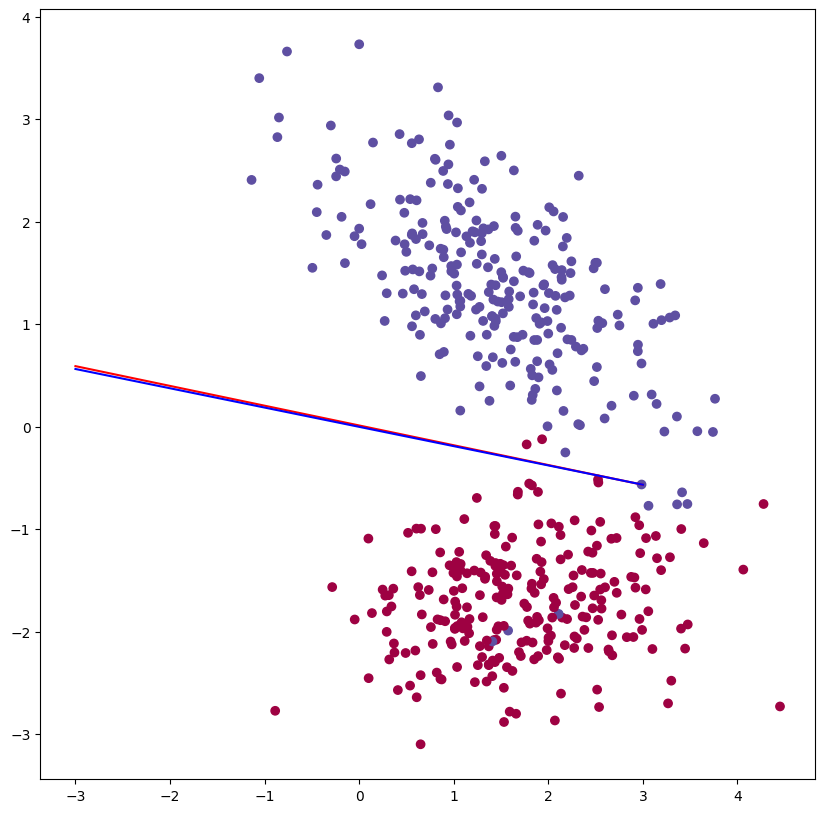

In [20]:
plt.figure(figsize=(10,10))
plt.plot(x_input,y_input,color='red')
plt.plot(x_input1,y_input1,color='blue')
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.Spectral)

### **Predicting New Data Points**

You can use this cell to manually input coordinates and see which class the trained model assigns to them.

In [24]:
def predict_point(x1, x2):
    point = np.array([[x1, x2]])
    prediction = lor.predict(point)
    probability = lor.predict_proba(point)
    print(f"Point ({x1}, {x2}) is classified as: Class {prediction[0]}")
    print(f"Confidence: {np.max(probability)*100:.2f}%")

# Example usage: Change these numbers to test different points!
predict_point(2.0, -2.0)

Point (2.0, -2.0) is classified as: Class 0
Confidence: 99.89%


### **Comparison: Custom GD vs. Scikit-learn**

In this section, we compare the statistical performance of the custom implementation against the industry-standard Scikit-learn model using multiple metrics:
- **Precision**: How many of the positive predictions were actually correct?
- **Recall**: How many of the actual positive cases did the model find?
- **F1-Score**: The harmonic mean of precision and recall.

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# 1. Get predictions for custom model
# We need to apply the learned weights to the test set manually
def custom_predict(X, coef, intercept):
    z = np.dot(X, coef) + intercept
    return (sigmoid(z) >= 0.5).astype(int)

y_pred_custom = custom_predict(X_test, coef_custom, intercept_custom)

# 2. Calculate Metrics
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Sklearn': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    'Custom GD': [
        accuracy_score(y_test, y_pred_custom),
        precision_score(y_test, y_pred_custom),
        recall_score(y_test, y_pred_custom),
        f1_score(y_test, y_pred_custom)
    ]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Metric,Sklearn,Custom GD
0,Accuracy,0.970000,0.960000
1,Precision,0.980769,0.980392
2,Recall,0.962264,0.943396
3,F1-Score,0.971429,0.961538


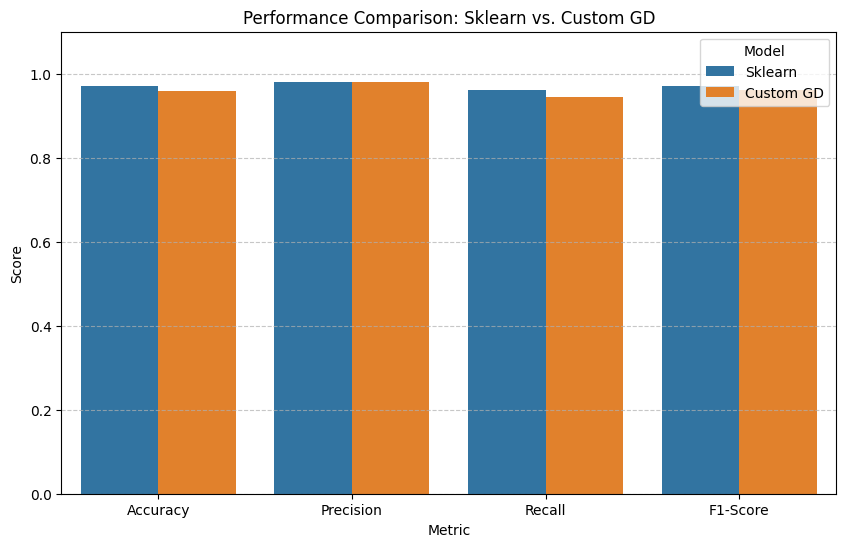

In [27]:
# 3. Visualization
import seaborn as sns
df_plot = df_metrics.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model')
plt.title('Performance Comparison: Sklearn vs. Custom GD')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Final Explanation: Comparing Custom GD and Scikit-learn**

**1. Metric Comparison:**
As shown in the table and bar chart, both models achieve nearly identical performance (96% vs 97% accuracy). This is because Logistic Regression is a convex optimization problem; both the Scikit-learn `sag` solver and our custom Gradient Descent are successfully converging toward the same global minimum of the Log-Loss function.

**2. Decision Boundaries:**
In the earlier visualization, the Red (Sklearn) and Blue (Custom) lines were almost perfectly overlapped. This confirms that the mathematical weights derived from your manual loops are equivalent to the professional implementation.

**3. Why use Scikit-learn over Custom?**
While the custom implementation works perfectly for this 2D case, Scikit-learn is preferred in production because:
- **Speed**: It uses compiled C/C++ extensions to handle large datasets much faster.
- **Stability**: It includes advanced features like automatic scaling, multiple optimization solvers (LBFGS, Liblinear), and regularization (L1/L2) to prevent overfitting.
- **Convenience**: It handles data preprocessing and validation seamlessly.

### **Final Explanation**

**1. Metric Comparison:**
As shown in the table and bar chart, both models achieve nearly identical performance. This is because Logistic Regression is a convex optimization problem; both the Scikit-learn `sag` solver and our custom Gradient Descent are successfully converging toward the same global minimum of the Log-Loss function.

**2. Decision Boundaries:**
In the earlier visualization, the Red (Sklearn) and Blue (Custom) lines were almost perfectly overlapped. This confirms that the mathematical weights derived from your manual loops are equivalent to the professional implementation.

**3. Why use Sklearn over Custom?**
While the custom implementation works perfectly for this 2D case, Scikit-learn is preferred in production because:
- **Speed**: It uses compiled C/C++ extensions to handle large datasets much faster.
- **Stability**: It includes advanced features like automatic scaling, multiple optimization solvers (LBFGS, Liblinear), and regularization (L1/L2) to prevent overfitting.